# Spatial and Temporal Analysis of Urban Issue Reports in Zurich #

## Data Preparation and Cleaning ##
The raw datasets are loaded and prepared for spatial and temporal analysis. The workflow includes data loading, variable selection, data type conversion, and the transformation of tabular data into geospatial formats. Furthermore, a consistent coordinate reference system (CH1903+ / LV95) is defined and applied to ensure spatial consistency across all datasets.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely import wkt
import geopandas as gpd
import mapclassify
import sys
import os
import importlib

sys.path.append(os.path.abspath("../scripts"))

import functions
importlib.reload(functions)

raw_reports = pd.read_csv("../data/raw/zwn_meldungen.csv")
raw_neighborhoods = pd.read_csv("../data/raw/quartiere_zürich.csv")
raw_population_size = pd.read_csv("../data/raw/populationsize_zh.csv")

# Keep only variables needed for spatial and temporal analysis
reports = raw_reports[["service_name","requested_datetime","e","n","status","updated_datetime"]]
neighborhoods = raw_neighborhoods[["qname","geometry"]]
population_size = raw_population_size[["QuarLang","AnzBestWir","StichtagDatJahr"]]

# Standardize column names to avoid merge conflicts across datasets
new_names_reports = {
    "service_name":"Category",
    "e":"East",
    "n":"North",
    "requested_datetime":"Report_time",
    "updated_datetime":"Resolved_time",
    }
reports = reports.rename(columns=new_names_reports)

new_names_neighborhoods = {
    "qname":"Neighborhoods",
    "geometry": "Geometry",
    }
neighborhoods = neighborhoods.rename(columns=new_names_neighborhoods)

new_names_population_size = {
    "QuarLang":"Neighborhoods",
    "AnzBestWir":"Population_size",
    "StichtagDatJahr":"Year"
    }
population_size = population_size.rename(columns=new_names_population_size)

# Verify data completeness before spatial analysis
reports.isna().sum()
neighborhoods.isna().sum()
population_size.isna().sum()


#-------------------------------------------------------------------------------------------------------------------------
# Prepare reports dataset
#-------------------------------------------------------------------------------------------------------------------------

reports["Report_time"] = pd.to_datetime(reports["Report_time"], format ="%Y-%m-%dT%H:%M:%S")
reports["Resolved_time"] = pd.to_datetime(reports["Resolved_time"], format ="%Y-%m-%dT%H:%M:%S")

# Create GeoDataFrame for spatial join
reports_gdf = gpd.GeoDataFrame(
    reports,
    geometry=gpd.points_from_xy(reports["East"], 
    reports["North"])
)
# Assign coordinate reference system (Swiss LV95 / EPSG:2056) for spatial join
reports_gdf = reports_gdf.set_crs(epsg=2056)


#-------------------------------------------------------------------------------------------------------------------------
# Prepare neighborhoods dataset
#-------------------------------------------------------------------------------------------------------------------------

neighborhoods["Geometry"] = neighborhoods["Geometry"].apply(wkt.loads)

# Create GeoDataFrame for spatial join
neighborhoods_gdf = gpd.GeoDataFrame(
    neighborhoods,
    geometry="Geometry")

# Assign coordinate reference system (Swiss LV95 / EPSG:2056) for spatial join
neighborhoods_gdf = neighborhoods_gdf.set_crs(epsg=2056)


#-------------------------------------------------------------------------------------------------------------------------
# Prepare poulation size dataset
#-------------------------------------------------------------------------------------------------------------------------

population_size_2025= population_size[population_size["Year"]	== 2025]


## Spatial Join ##
A left join is used to retain all reports, even if some do not match a neighborhood polygon.\
Intersects is preferred over within to minimize unmatched observations

In [4]:
reports_gdf_with_neighborhoods_gdf = gpd.sjoin(reports_gdf,neighborhoods_gdf, how="left", predicate ="intersects")

## Question 1: How does the number of reports vary across neighborhoods?
To answer this question, reports are aggregated at the neighborhood level and normalized by population size for better comparison between neighborhoods. The results are visualized using a choropleth map. Class breaks are determined using Natural Breaks classification. The number of class breaks is chosen with the help of a histogram.

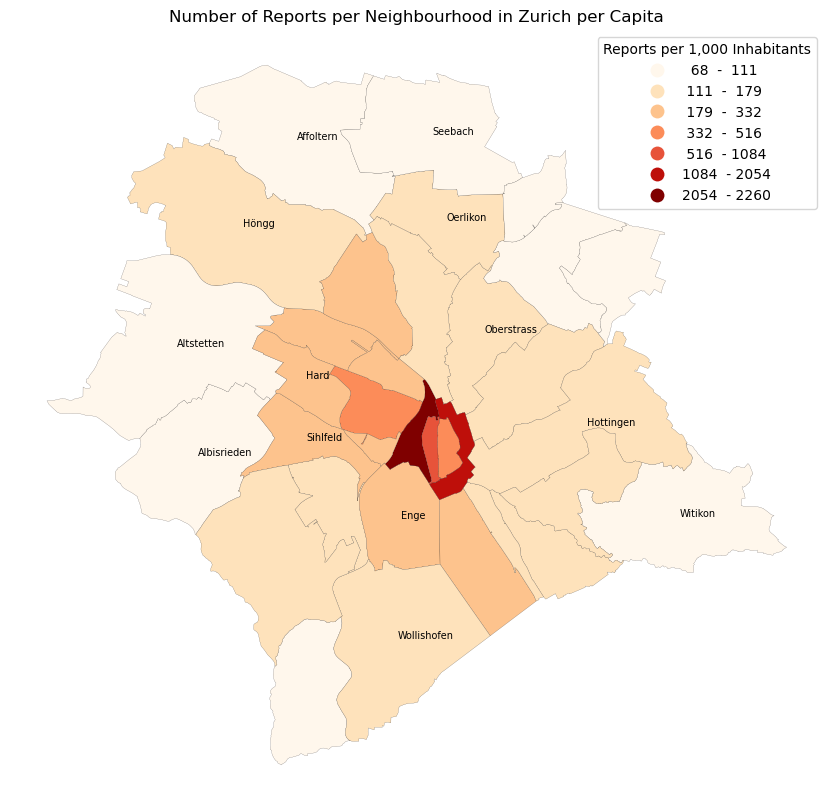

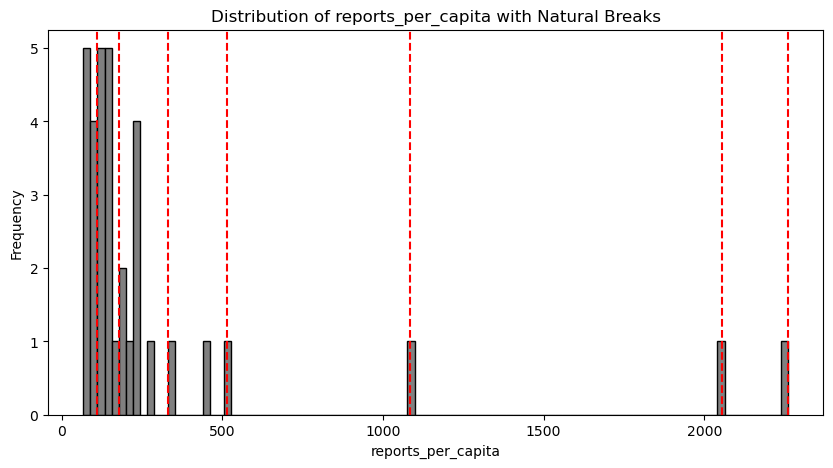

In [5]:
#---------------------------------------------------------------------------------------------------------------------
# Build Analysis Dataset
#---------------------------------------------------------------------------------------------------------------------

# # Aggregate reports per neighborhood to compare reporting intensity across neighborhoods
reports_count = reports_gdf_with_neighborhoods_gdf.groupby(["Neighborhoods"]).size().reset_index(name="count")

reports_count_gdf = neighborhoods_gdf.merge(reports_count, on="Neighborhoods",how="left")
reports_count_pop_gdf = reports_count_gdf.merge(population_size_2025, on="Neighborhoods",how="left")

# Scale values per 1,000 inhabitants for better readability
reports_count_pop_gdf["reports_per_capita"] = (reports_count_pop_gdf["count"]/reports_count_pop_gdf["Population_size"] *1000)

#----------------------------------------------------------------------------------------------
# Create Chlorpleth Map
#----------------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(20,10)) 

reports_count_pop_gdf.plot(
    column="reports_per_capita",
    scheme = "naturalbreaks",
    k = 7,
    edgecolor = "black",
    legend=True,
    linewidth = 0.1,
    cmap="OrRd",
    ax=ax, 
    legend_kwds={"title": "Reports per 1,000 Inhabitants","fmt": "{:.0f}"})

ax.set_title("Number of Reports per Neighbourhood in Zurich per Capita")
ax.axis("off")

# improve map readability by enhancing legend formatting and adding neighborhoods labels
functions.clean_legend_labels(ax)
functions.add_labels_zurich(ax,reports_count_pop_gdf,names=["Affoltern","Seebach","Oerlikon","Höngg","Altstetten",
                                                            "Albisrieden","Enge","Wollishofen","Witikon","Hottingen",
                                                            "Sihlfeld","Hard","Oberstrass"])

plt.show()

#----------------------------------------------------------------------------------------------------------------------------------------
# Create Histogram
#----------------------------------------------------------------------------------------------------------------------------------------
functions.histogram_natural_breaks(reports_count_pop_gdf,column="reports_per_capita",k=7)


## Question 2: What categories of problems are most frequently reported in each neighbourhood? ##
To answer this question the reports are first grouped by neighborhood and category to calculate the frequency of each report type.\
The dominant category per neighborhoood is then identified. The results are visualized using a categorical map.

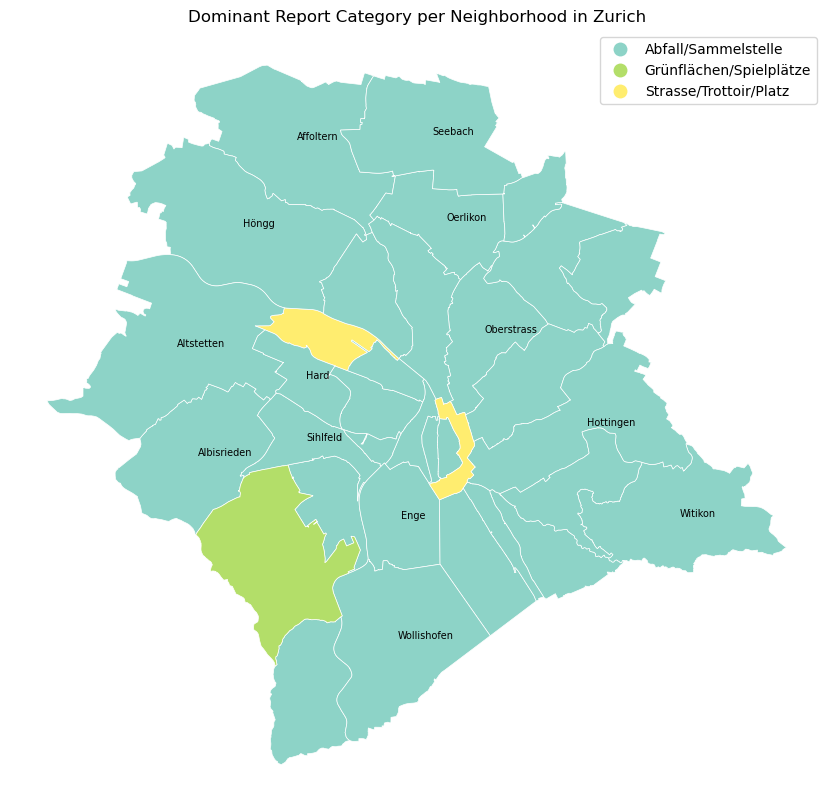

In [6]:
#---------------------------------------------------------------------------------------------------
# Build Analysis Dataset
#---------------------------------------------------------------------------------------------------
count_category = reports_gdf_with_neighborhoods_gdf.groupby(["Neighborhoods","Category"]).size().reset_index(name="count")


# Extract the most reported category per neighborhood to compare spatial differences in main issue types
maxcount = count_category.sort_values(["Neighborhoods", "count"], ascending=[True, False]).drop_duplicates("Neighborhoods")

maxcount_gdf = neighborhoods_gdf.merge(maxcount, on="Neighborhoods",how="left")

#---------------------------------------------------------------------------------------------------------
# Create Categoric Map
#---------------------------------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(20,10))

maxcount_gdf.plot(
    column="Category",
    categorical=True,
    edgecolor = "white",
    legend=True,
    linewidth = 0.5,
    cmap = "Set3",
    ax=ax,)
 
ax.axis("off")
ax.set_title("Dominant Report Category per Neighborhood in Zurich") 

functions.add_labels_zurich(ax,maxcount_gdf,names=["Affoltern","Seebach","Oerlikon","Höngg","Altstetten",
                                                            "Albisrieden","Enge","Wollishofen","Witikon","Hottingen",
                                                            "Sihlfeld","Hard","Oberstrass"])
plt.show()




## Question 3: Is the "Abfall/Sammelstelle" issue concentrated in particular neighbourhoods? ##
To answer this question the reports are filtered to focus on the category "Abfall/Sammelstelle". Report count are then aggregated for each neighborhood. Report counts are than normalized by population to enable comparison between neighborhoods. A chloropleth map is used to visualize the distribution of the reports.  Class breaks are determined using Natural Breaks classification. The number of class breaks is chosen with the help of a histogram.



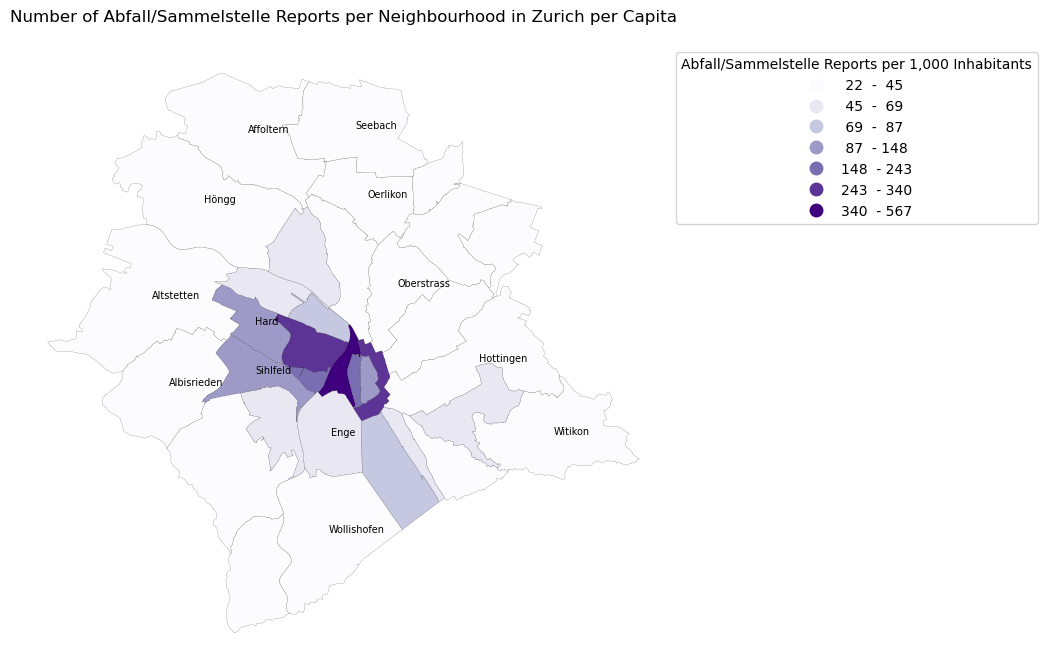

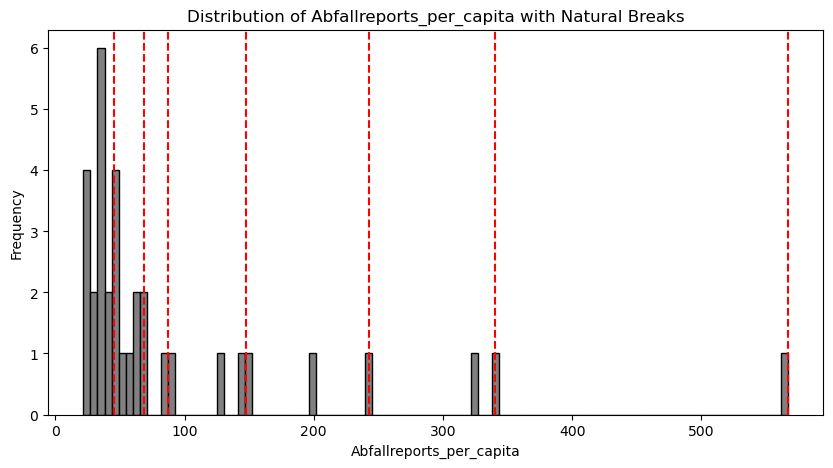

In [7]:
# ------------------------------------------------------------
# Build Analysis dataset
# ------------------------------------------------------------

#filter reports to focus on Abfall/Sammelstelle issues only
filtered_category = count_category[count_category["Category"]=="Abfall/Sammelstelle"]

filtered_category=population_size_2025.merge(filtered_category, on = "Neighborhoods", how="left")
filtered_category_gdf=neighborhoods_gdf.merge(filtered_category, on="Neighborhoods",how="left")

# Scale values per 1,000 inhabitants for better readability
filtered_category_gdf["Abfallreports_per_capita"] = (filtered_category_gdf["count"]/filtered_category_gdf["Population_size"]*1000)


#---------------------------------------------------------------------------------------------------------
# Create Chloropleth Map
#---------------------------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16,8)) 


filtered_category_gdf.plot(
    column="Abfallreports_per_capita",
    scheme = "naturalbreaks",
    k = 7,
    edgecolor = "black",
    legend=True,
    linewidth = 0.1,
    cmap="Purples",
    ax=ax, 
    legend_kwds={"title": "Abfall/Sammelstelle Reports per 1,000 Inhabitants","fmt": "{:.0f}","loc":"upper left","bbox_to_anchor":(1, 1)})
              
ax.set_title("Number of Abfall/Sammelstelle Reports per Neighbourhood in Zurich per Capita")
ax.axis("off")

# improve map readability by enhancing legend formatting and adding neighborhoods labels
functions.clean_legend_labels(ax)
functions.add_labels_zurich(ax,filtered_category_gdf,names=["Affoltern","Seebach","Oerlikon","Höngg","Altstetten",
                                                            "Albisrieden","Enge","Wollishofen","Witikon","Hottingen",
                                                            "Sihlfeld","Hard","Oberstrass"])

#---------------------------------------------------------------------------------------------------------
# Create Histogram
#---------------------------------------------------------------------------------------------------------
functions.histogram_natural_breaks(filtered_category_gdf,column="Abfallreports_per_capita",k=7)







## Question 4: How does the processing time for "Abfal/Sammelstelle" reports vary across neighborhoods in Zurich ##
To answer this question only resolved reports are included. The dataset is filtered to retain only "Abfall/Sammelstelle" reports. The processing time is calculated as the time between report submission and resolution. Mean processing time is then aggregated to each neighborhood. A chloropleth map is used to visualize the distribution of the processing time. Class breaks are determined using Natural Breaks classification. The number of class breaks is chosen with the help of a histogram.

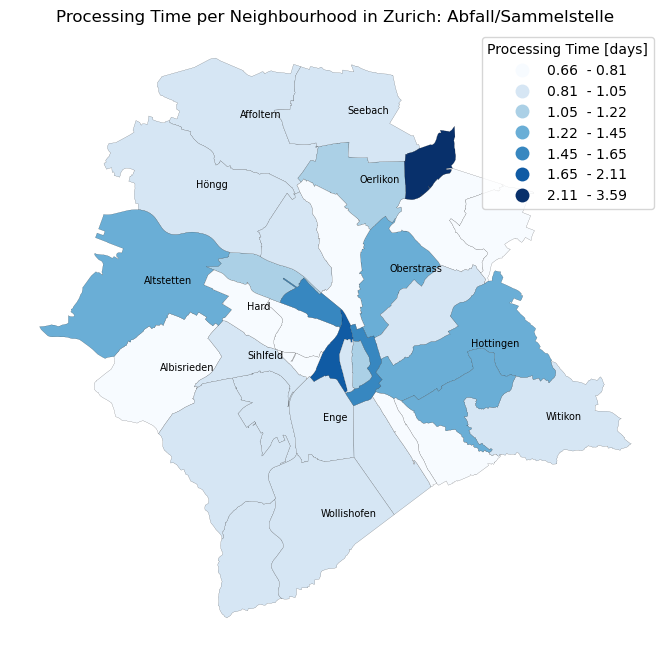

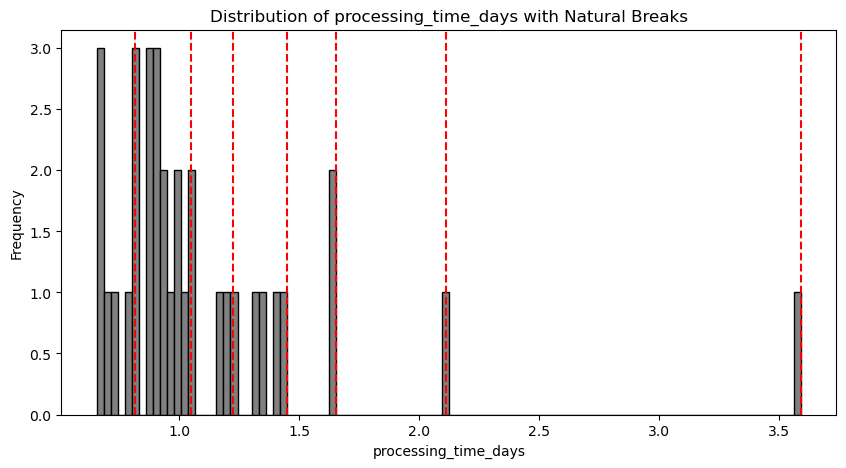

In [8]:
# ----------------------------------------------------------------------------------------------------------------------------------------
# Build Analysis dataset
# ----------------------------------------------------------------------------------------------------------------------------------------

# Only resolved reports are included, since processing time cannot be calculated for unresolved cases
reports_fixed = reports_gdf_with_neighborhoods_gdf [reports_gdf_with_neighborhoods_gdf["status"] =="fixed - council"]

mean_days = functions.calculate_mean_processing_time(reports_fixed,"Abfall/Sammelstelle")
mean_days_gdf = neighborhoods_gdf.merge(mean_days, on="Neighborhoods",how="left")

#--------------------------------------------------------------------------------
# Create Choropleth Map
#--------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16,8)) 

mean_days_gdf.plot(column="processing_time_days",
            scheme = "naturalbreaks",
            k = 7,
            edgecolor = "black",
            legend=True,
            linewidth = 0.1,
            cmap="Blues",
            ax=ax, #draw the axes on the axes we creaed
            legend_kwds={
                "title": "Processing Time [days]",})
ax.set_title("Processing Time per Neighbourhood in Zurich: Abfall/Sammelstelle")
ax.axis("off")

# improve map readability by enhancing legend formatting and adding neighborhoods labels
functions.clean_legend_labels(ax)
functions.add_labels_zurich(ax,mean_days_gdf,names=["Affoltern","Seebach","Oerlikon","Höngg","Altstetten",
                                                "Albisrieden","Enge","Wollishofen","Witikon","Hottingen",
                                                "Sihlfeld","Hard","Oberstrass"])


#--------------------------------------------------------------------------------------------------------------------------------------------------------------
# Create histogram
#----------------------------------------------------------------------------------------------------------------------------------------------------------
functions.histogram_natural_breaks(mean_days_gdf,column="processing_time_days",k=7)


## Question 5: How do report volumes change overtime per category in Zurich ? ##
To answer this question, report data is grouped by time and category and aggregated into monthly counts. For the long-term analysis a time series is generated by resampling the data monthly across multiple years. For the short-term analysis the monthly reports data is restricted to a single year. Both analyses are implemented through a reusable function. The resulting category trends are visualized as line plots. Each category is represented by a different color.

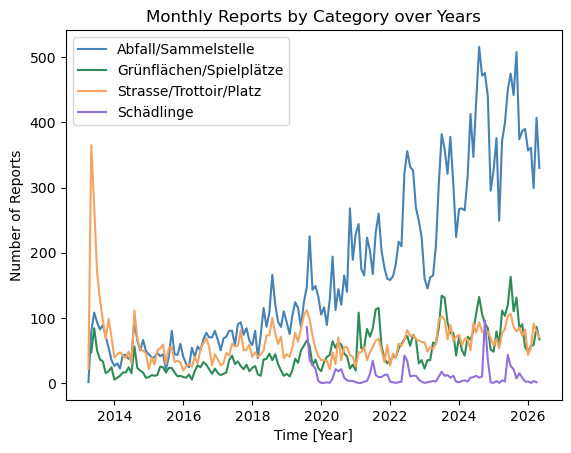

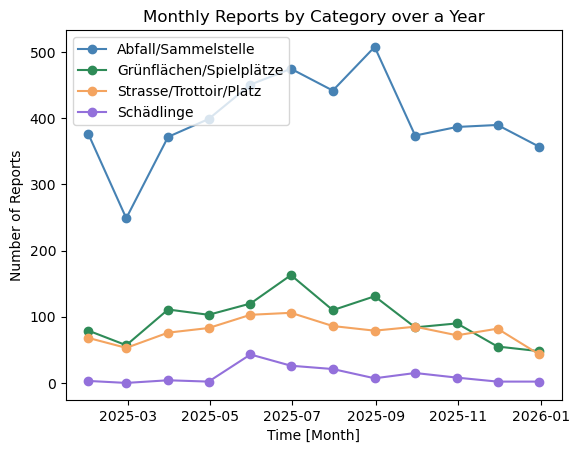

In [9]:
# Visualize long-term temporal trends to identify structural changes over multiple years
functions.plot_category_over_years(reports_gdf_with_neighborhoods_gdf,["Abfall/Sammelstelle","Grünflächen/Spielplätze","Strasse/Trottoir/Platz","Schädlinge"])

# Visualize monthly variation within a year to identify seasonal patterns
functions.plot_category_over_a_year(reports_gdf_with_neighborhoods_gdf,["Abfall/Sammelstelle","Grünflächen/Spielplätze","Strasse/Trottoir/Platz","Schädlinge"],year=2025)
